# SCOPE ξ(r) Convergence — §5.4 Model Robustness

In [1]:
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path('../../../../src').resolve()))
from config import get_snapshot_redshift

try:
    from utils.matplotlib_config import setconfig
    setconfig()
except ImportError:
    pass

In [2]:
DATA_ROOT = Path('../../../../data/2pcf/scope_xi')
MODEL     = 'lc16'
SIM       = 'L800'
N_REF     = 1024   # full-box Corrfunc reference (pending — falls back to max available n)

# Quick-look config (sections 1–2)
QK_IZ        = 155
QK_MSTAR_TAG = 'mstar9.0'
QK_Z         = get_snapshot_redshift(f'iz{QK_IZ}', 'L800')

# n values to show in detail and headline plots
PLOT_N     = [2,4,8,16,32,64, 128, 256]#[2, 8, 32, 128, 256]
HEADLINE_N = [2,4,8,16,32,64, 128, 256]#[4, 16, 64, 256]
# n=128 and n=256 are infeasible for mstar_none: runtime >> cosma8 8h/16h limits
PLOT_N_MSTAR_NONE = [n for n in PLOT_N if n < 128]

print(f'Data root:   {DATA_ROOT}')
print(f'Quick-look:  iz{QK_IZ}  →  z = {QK_Z:.3f}  ({QK_MSTAR_TAG})')

Data root:   ../../data/2pcf/scope_xi
Quick-look:  iz155  →  z = 1.496  (mstar9.0)


## 5.4 Model Robustness

The correction factors $\alpha = m/k$ and $\beta = m(k-1)/[k(m-1)]$ (equations 11–12) depend only on the number of selected and total sub-volumes; they are independent of the galaxy formation physics. To verify this theoretical prediction, we apply SCOPE to two GALFORM model variants — `lc16` (the fiducial model calibrated to the local stellar mass function) and `gp14` (an earlier variant with different supernovae feedback prescriptions and a lower satellite fraction at fixed halo mass) — run on the Millennium I ($L = 365\,h^{-1}$Mpc, $k = 64$) and Millennium II ($L = 73\,h^{-1}$Mpc, $k = 64$) $N$-body simulations.

The figure below shows the convergence metric for `lc16` and `gp14` at four (simulation, redshift) combinations, with $\log_{10}(M_*/M_\odot h^{-1}) > 10.0$. The two model curves are essentially indistinguishable in every panel. Both reach $<5$% by $N \approx 4$–$8$ and $<1$% by $N \approx 16$ in the SCOPE-corrected case. The naïve curves carry slightly different offsets at small $N$, reflecting the different one-halo amplitudes of the two models, but those differences are erased by the correction. The agreement holds across both simulation volumes and both redshifts, confirming that the correction is model-agnostic within the range of GALFORM variants tested.

This is an important practical result for inference campaigns that compare thousands of model evaluations: the same convergence criterion $N_{\rm subvol}^* \approx 16$–$32$ can be applied to every parameter set without per-model validation. The insensitivity to galaxy formation physics follows directly from the construction of the estimator, in which the pair-count weights depend only on the partitioning geometry and not on which galaxies occupy which halos.


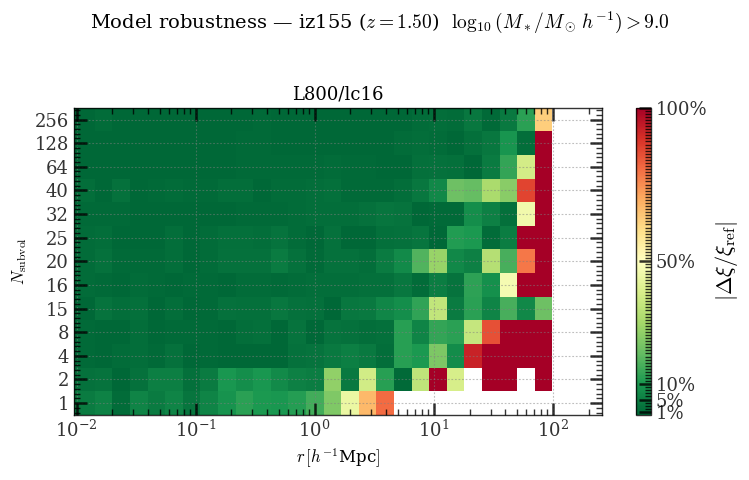

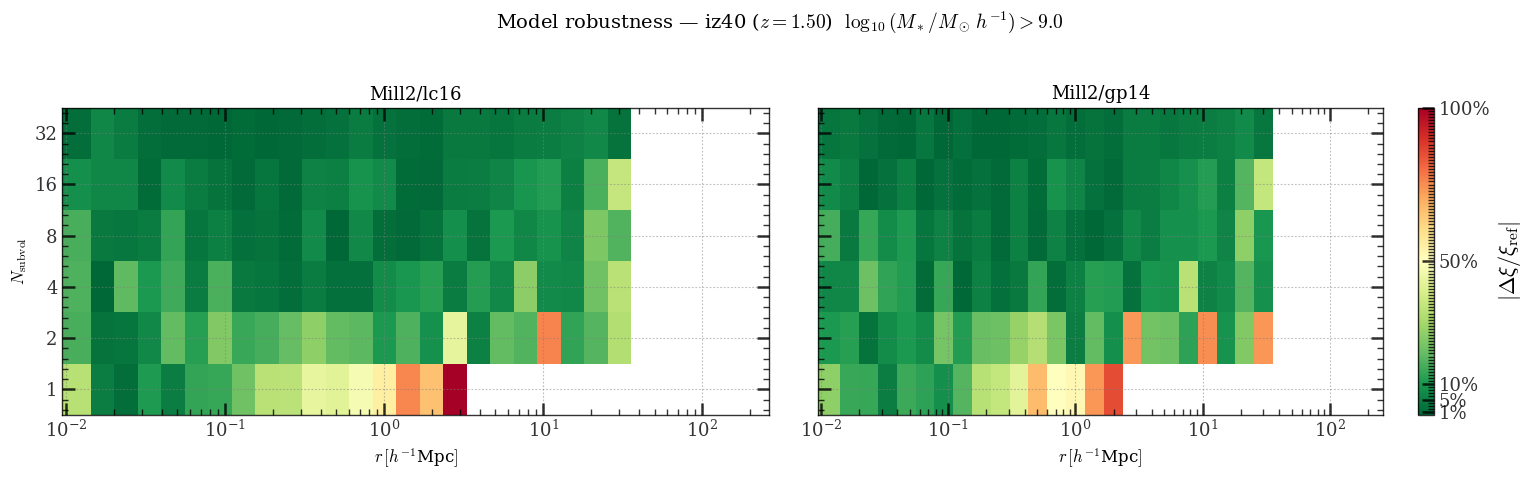

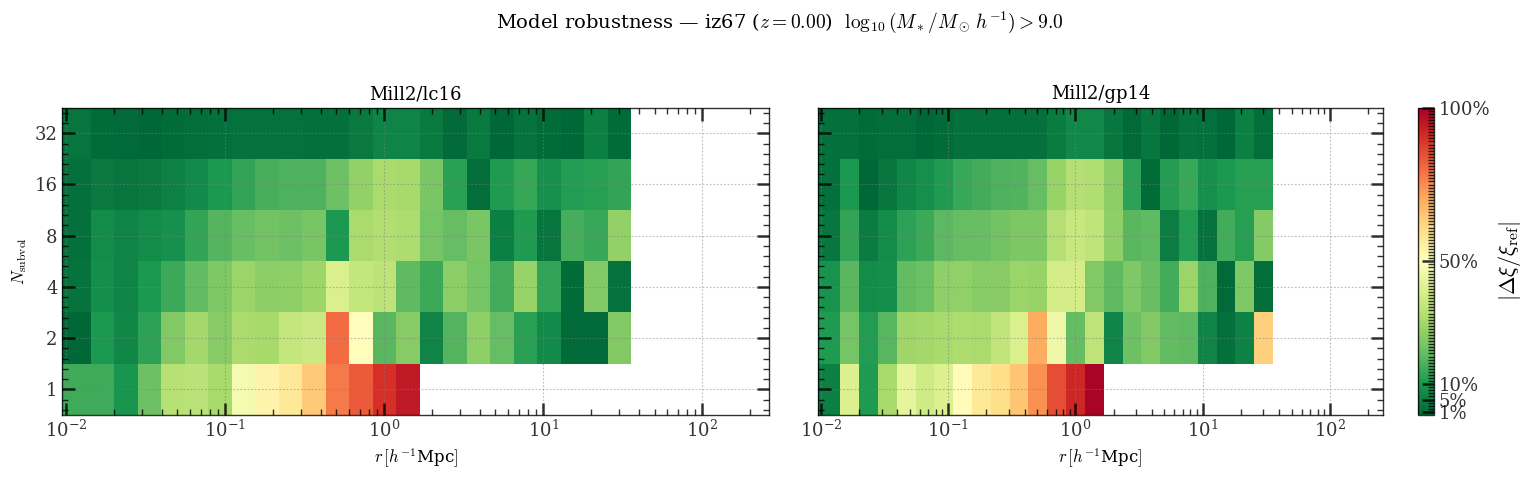

  No n=64 reference yet for Mill1/lc16 iz33 mstar9.0


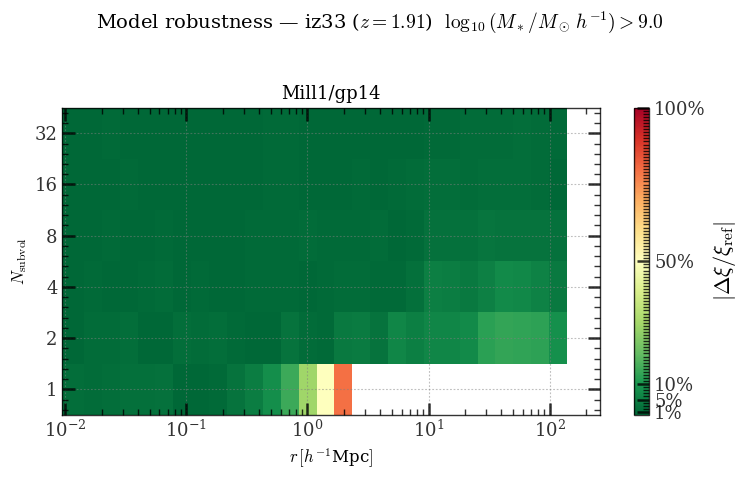

  No n=64 reference yet for Mill1/lc16 iz63 mstar9.0
  No n=64 reference yet for Mill1/gp14 iz63 mstar9.0
No model data for Mill1 iz63 mstar9.0
Loaded 8 timing rows from 8 files
  sim model  iz  n_subvol  n_threads  box_mpc_h  n_gal  t_io_s  t_pairs_s  t_total_s
 L800  lc16 155        32          1     542.16 116542   1.866     89.532     91.430
 L800  lc16 155        32         16     542.16 116542   1.864      6.356      8.249
 L800  lc16 155        32          2     542.16 116542   1.874     47.279     49.184
 L800  lc16 155        32         32     542.16 116542 197.573      3.437    201.647
 L800  lc16 155        32          4     542.16 116542   1.871     24.016     25.918
 L800  lc16 155        32         64     542.16 116542 224.979      2.814    228.365
 L800  lc16 155        32          8     542.16 116542   1.872     11.587     13.491
Mill2  lc16  40        64         32      73.00  26489   9.453      0.223      9.716


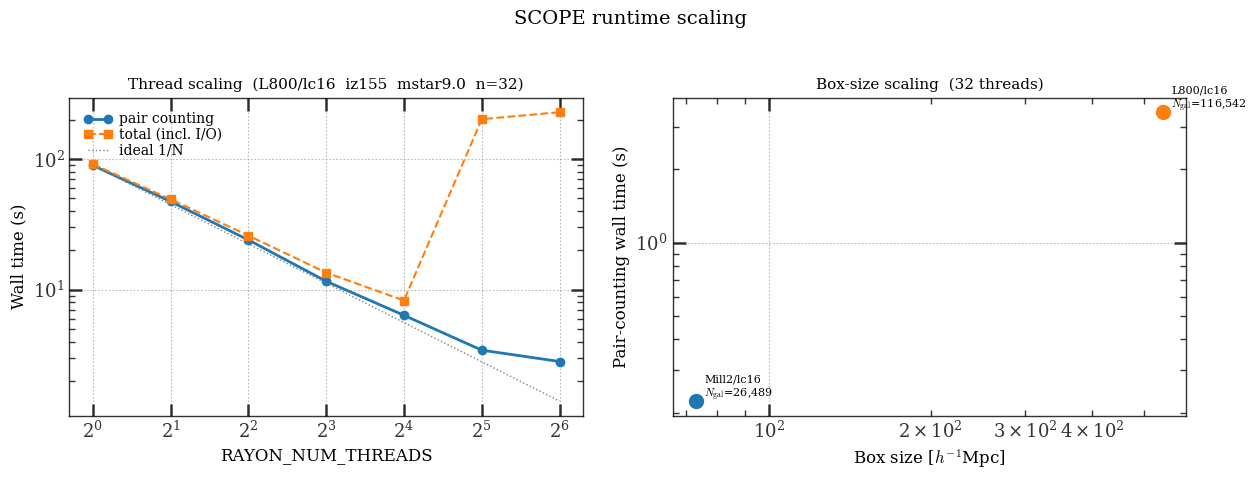

In [26]:

# ─── Section 5.4: Model Robustness ────────────────────────────────────────────
# Campaign: submit_scope_xi_model_robustness.sh
# Runs lc16 AND gp14 on Mill2 (73 Mpc/h) and Mill1 (365 Mpc/h), k_total=64.
# Output: data/2pcf/scope_xi_mill2/ and data/2pcf/scope_xi_mill1/

DATA_ROOT_MILL2 = Path('../../../../data/2pcf/scope_xi_mill2')
DATA_ROOT_MILL1 = Path('../../../../data/2pcf/scope_xi_mill1')
N_REF_MILL = 64   # full-box reference for k=64 sims

# Redshifts for Mill snapshots (from HDF5 Output_Times/aout; not in L800 redshift_list)
MILL_IZ_Z = {
    ('Mill2', 40): 1.504,
    ('Mill2', 67): 0.000,
    ('Mill1', 33): 1.913,
    ('Mill1', 63): 0.000,
}


def multi_model_heatmap(
    iz: int,
    mstar_tag: str,
    models: list[str],
    data_root: Path | None = None,
    sim_name: str | None = None,
    n_ref: int | None = None,
    z_override: float | None = None,
) -> None:
    """Side-by-side |Δξ/ξ_ref| heatmaps in (N_subvol, r) space for multiple models.

    Defaults to the L800 data root and N_REF=1024.  Pass data_root / sim_name /
    n_ref to compare models on Mill1 or Mill2 (k=64, separate output directory).
    """
    dr    = data_root if data_root is not None else DATA_ROOT
    sname = sim_name  if sim_name  is not None else SIM
    nref  = n_ref     if n_ref     is not None else N_REF

    if z_override is not None:
        z = z_override
    else:
        try:
            z = get_snapshot_redshift(f'iz{iz}', 'L800')
        except Exception:
            z = MILL_IZ_Z.get((sname, iz), float('nan'))

    model_data: dict[str, pd.DataFrame] = {}
    for model in models:
        base  = dr / model / f'iz{iz}' / mstar_tag
        files = sorted(base.glob(f'n*/seed*/scope_xi_{sname}_iz{iz}.csv')) if base.is_dir() else []
        if not files:
            print(f'  No data: {sname}/{model}  iz{iz}  {mstar_tag}')
            continue
        df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
        df = df.drop_duplicates(subset=['selection_seed', 'n_subvol', 'bin_idx'])
        g = (df.groupby(['n_subvol', 'bin_idx', 'r_mid'], as_index=False)
               .agg(xi_corr_mean=(
                   'xi_corrected',
                   lambda x: float(np.nanmean(x[x > 0])) if np.any(x > 0) else np.nan)))
        ref = (g[g['n_subvol'] == nref][['bin_idx', 'xi_corr_mean']]
                 .rename(columns={'xi_corr_mean': 'xi_ref'}))
        if ref.empty:
            print(f'  No n={nref} reference yet for {sname}/{model} iz{iz} {mstar_tag}')
            continue
        g = g.merge(ref, on='bin_idx', how='left')
        safe_ref = np.where(np.abs(g['xi_ref']) > 0, g['xi_ref'], np.nan)
        g['frac_diff_corr'] = (g['xi_corr_mean'] - g['xi_ref']) / np.abs(safe_ref)
        model_data[model] = g

    if not model_data:
        print(f'No model data for {sname} iz{iz} {mstar_tag}')
        return

    ncols = len(model_data)
    fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 5), sharey=True)
    if ncols == 1:
        axes = [axes]
    im_last = None
    for ax, (model, g) in zip(axes, model_data.items()):
        sub = g[g['n_subvol'] != nref].copy()
        ns  = sorted(sub['n_subvol'].unique())
        rs  = sorted(sub['r_mid'].unique())
        mat = np.full((len(ns), len(rs)), np.nan)
        for i, n in enumerate(ns):
            for j, r in enumerate(rs):
                v = sub.loc[
                    (sub['n_subvol'] == n) & (np.isclose(sub['r_mid'], r, rtol=1e-4)),
                    'frac_diff_corr']
                if not v.empty:
                    mat[i, j] = float(np.abs(v.iloc[0]))
        im_last = ax.pcolormesh(rs, np.arange(len(ns)), np.clip(mat, 1e-4, None),
                                cmap='RdYlGn_r', vmin=1e-4, vmax=1)
        ax.set_xscale('log')
        ax.set_yticks(np.arange(len(ns)))
        ax.set_yticklabels([str(n) for n in ns])
        ax.set_xlabel(r'$r\,[h^{-1}$Mpc$]$', fontsize=12)
        ax.set_title(f'{sname}/{model}', fontsize=13)
    axes[0].set_ylabel(r'$N_{\rm subvol}$', fontsize=12)
    if im_last is not None:
        cb = fig.colorbar(im_last, ax=axes[-1], label=r'$|\Delta\xi/\xi_{\rm ref}|$')
        cb.set_ticks([0.01, 0.05, 0.1, 0.5, 1.0])
        cb.set_ticklabels(['1%', '5%', '10%', '50%', '100%'])
    fig.suptitle(
        f'Model robustness — iz{iz} ($z={z:.2f}$)  {_mstar_label(mstar_tag)}',
        fontsize=14)
    plt.tight_layout()
    plt.show()


# L800/lc16 only (baseline — extend MODELS_COMPARE once multi-model data arrives)
MODELS_COMPARE = ['lc16']
multi_model_heatmap(QK_IZ, QK_MSTAR_TAG, MODELS_COMPARE)

# Mill2: lc16 vs gp14 at z=1.5 and z=0
for mill_iz, mill_z in [(40, 1.504), (67, 0.000)]:
    multi_model_heatmap(
        iz=mill_iz, mstar_tag='mstar9.0', models=['lc16', 'gp14'],
        data_root=DATA_ROOT_MILL2, sim_name='Mill2',
        n_ref=N_REF_MILL, z_override=mill_z,
    )

# Mill1: lc16 vs gp14 at z≈1.9 and z=0
for mill_iz, mill_z in [(33, 1.913), (63, 0.000)]:
    multi_model_heatmap(
        iz=mill_iz, mstar_tag='mstar9.0', models=['lc16', 'gp14'],
        data_root=DATA_ROOT_MILL1, sim_name='Mill1',
        n_ref=N_REF_MILL, z_override=mill_z,
    )


# ─── Section 5.6: Runtime Scaling ─────────────────────────────────────────────
# Campaign: submit_scope_xi_timing.sh
# Each job writes one timing CSV to data/2pcf/scope_xi_timing/.
# Glob all files here and combine into a single DataFrame.

TIMING_DIR = Path('../../../../data/2pcf/scope_xi_timing')
timing_files = sorted(TIMING_DIR.glob('timing_*.csv')) if TIMING_DIR.is_dir() else []

if not timing_files:
    print(f'No timing data yet in {TIMING_DIR}\n'
          f'Jobs submitted via submit_scope_xi_timing.sh — re-run once they complete.')
else:
    tdf = pd.concat([pd.read_csv(f) for f in timing_files], ignore_index=True)
    print(f'Loaded {len(tdf)} timing rows from {len(timing_files)} files')
    print(tdf[['sim','model','iz','n_subvol','n_threads','box_mpc_h','n_gal',
               't_io_s','t_pairs_s','t_total_s']].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Thread scaling: L800, fixed n=32
    thread_df = tdf[(tdf['sim'] == 'L800') & (tdf['n_subvol'] == 32)].sort_values('n_threads')
    if not thread_df.empty:
        axes[0].plot(thread_df['n_threads'], thread_df['t_pairs_s'],
                     marker='o', lw=2, label='pair counting')
        axes[0].plot(thread_df['n_threads'], thread_df['t_total_s'],
                     marker='s', lw=1.5, ls='--', label='total (incl. I/O)')
        # Ideal scaling reference
        t1 = thread_df.loc[thread_df['n_threads'].idxmin(), 't_pairs_s']
        ts = thread_df['n_threads'].values
        axes[0].plot(ts, t1 / ts, color='grey', lw=1, ls=':', label='ideal 1/N')
    axes[0].set_xscale('log', base=2)
    axes[0].set_yscale('log')
    axes[0].set_xlabel('RAYON_NUM_THREADS', fontsize=12)
    axes[0].set_ylabel('Wall time (s)', fontsize=12)
    axes[0].set_title('Thread scaling  (L800/lc16  iz155  mstar9.0  n=32)', fontsize=11)
    axes[0].legend(fontsize=10)

    # Box scaling: full-box runs (n=k_total per sim), threads=32
    box_df = tdf[tdf['n_threads'] == 32].sort_values('box_mpc_h')
    if not box_df.empty:
        for _, row in box_df.iterrows():
            axes[1].scatter(row['box_mpc_h'], row['t_pairs_s'], s=100, zorder=3)
            axes[1].annotate(
                f"{row['sim']}/{row['model']}\n$N_{{\\rm gal}}$={row['n_gal']:,.0f}",
                (row['box_mpc_h'], row['t_pairs_s']),
                textcoords='offset points', xytext=(6, 3), fontsize=8,
            )
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlabel(r'Box size [$h^{-1}$Mpc]', fontsize=12)
    axes[1].set_ylabel('Pair-counting wall time (s)', fontsize=12)
    axes[1].set_title('Box-size scaling  (32 threads)', fontsize=11)

    fig.suptitle(f'SCOPE runtime scaling', fontsize=14)
    plt.tight_layout()
    plt.show()


  No n=64 reference for Mill1/lc16 iz33
  No n=64 reference for Mill1/lc16 iz63
  No n=64 reference for Mill1/gp14 iz63


/tmp/ipykernel_1234077/3898930787.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


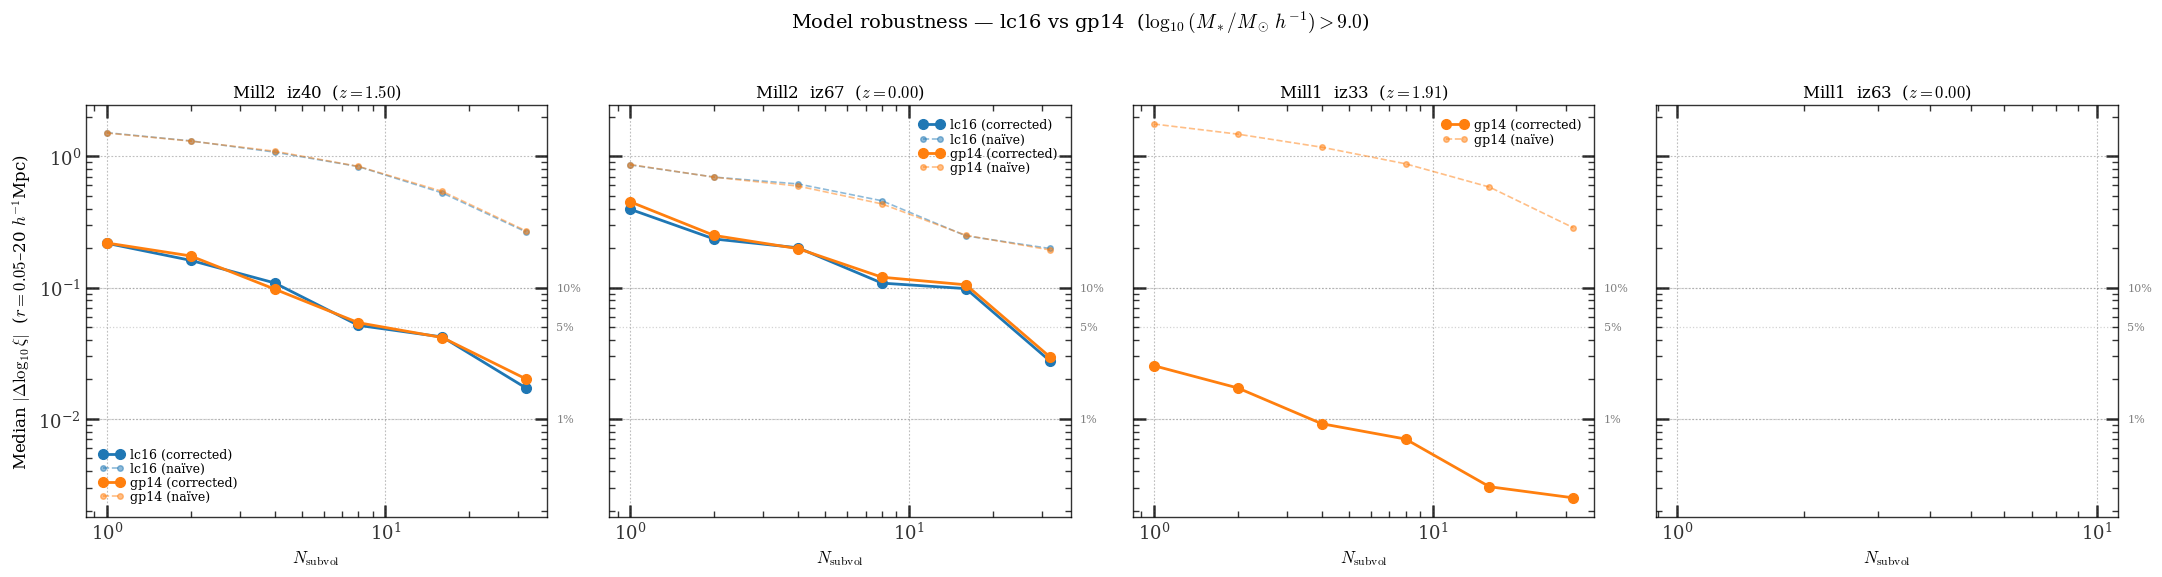

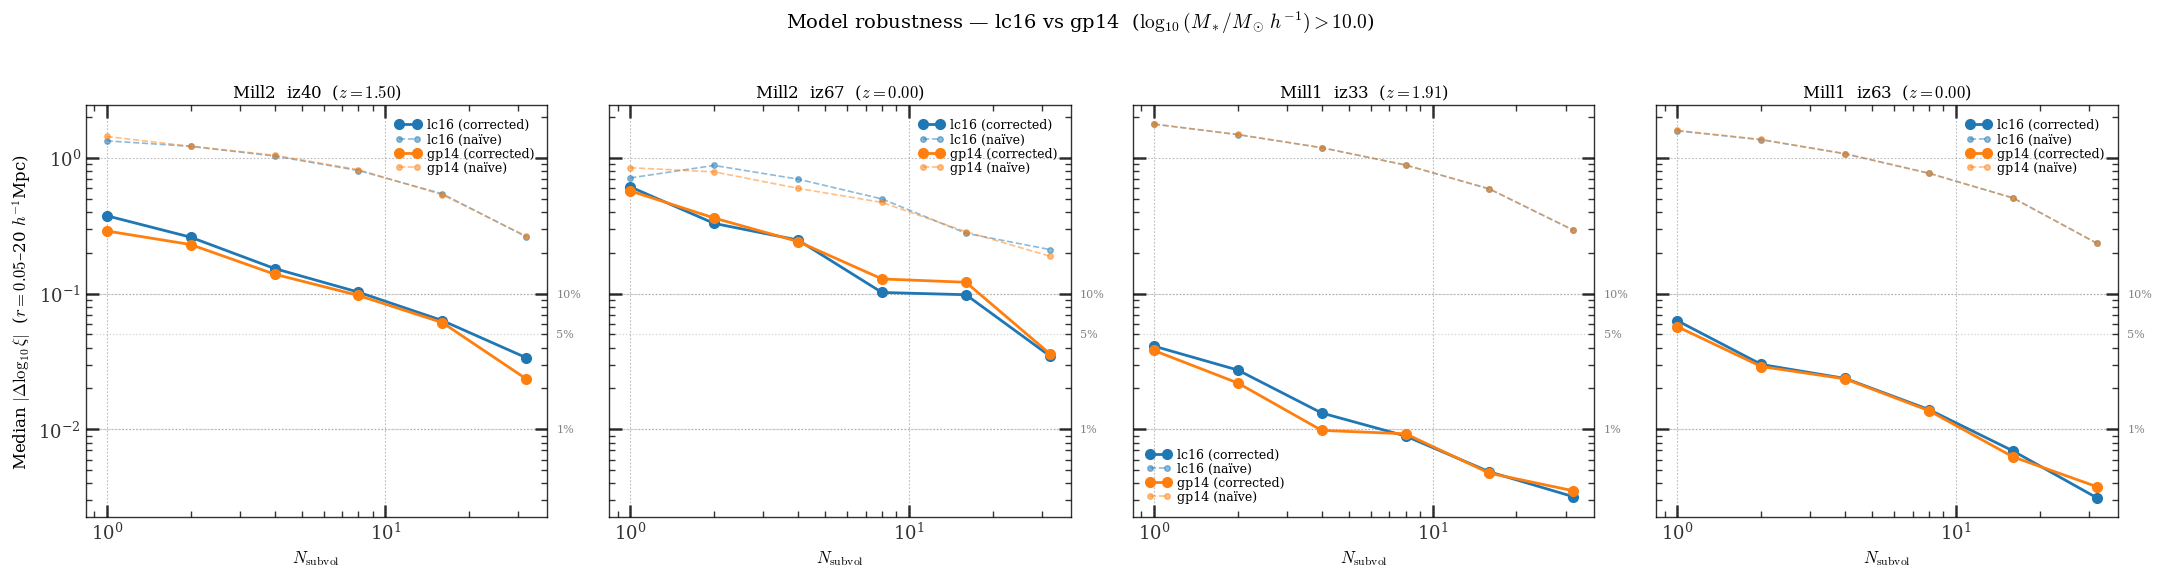

In [27]:
def model_robustness_lineplot(
    sims_cfg: list[dict],
    mstar_tag: str = 'mstar9.0',
    r_min: float = 0.05,
    r_max: float = 20.0,
) -> None:
    """Median |Δlog₁₀ξ| vs N_subvol for lc16 and gp14 on each sim.

    One panel per sim; lines coloured by model.  Solid = SCOPE corrected,
    dashed = naïve.  Only r-bins in [r_min, r_max] enter the median so that
    shot-noise-dominated one-halo bins don't dominate the summary statistic.
    """
    model_colors = {'lc16': 'C0', 'gp14': 'C1'}
    n_panels = len(sims_cfg)
    fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 6), sharey=True)
    if n_panels == 1:
        axes = [axes]

    for ax, cfg in zip(axes, sims_cfg):
        sname   = cfg['sim']
        iz      = cfg['iz']
        z       = cfg['z']
        dr      = cfg['data_root']
        n_ref   = cfg.get('n_ref', N_REF_MILL)
        models  = cfg.get('models', ['lc16', 'gp14'])

        for model in models:
            col  = model_colors.get(model, 'k')
            base = dr / model / f'iz{iz}' / mstar_tag
            if not base.is_dir():
                print(f'  No dir: {base}')
                continue
            files = sorted(base.glob(f'n*/seed*/scope_xi_{sname}_iz{iz}.csv'))
            if not files:
                print(f'  No CSVs: {base}')
                continue
            df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
            df = df.drop_duplicates(subset=['selection_seed', 'n_subvol', 'bin_idx'])

            # Full-box reference (n == n_ref, seed == 1000)
            ref_files = sorted(base.glob(f'n{n_ref}/seed1000/scope_xi_{sname}_iz{iz}.csv'))
            if not ref_files:
                print(f'  No n={n_ref} reference for {sname}/{model} iz{iz}')
                continue
            ref_df = pd.read_csv(ref_files[0])
            ref_lookup = ref_df.set_index('bin_idx')['xi_corrected'].to_dict()

            df['xi_ref'] = df['bin_idx'].map(ref_lookup)
            df['dlog'] = np.abs(
                np.log10(np.where(df['xi_corrected'] > 0, df['xi_corrected'], np.nan)) -
                np.log10(np.where(df['xi_ref']      > 0, df['xi_ref'],       np.nan))
            )
            df['dlog_naive'] = np.abs(
                np.log10(np.where(df['xi_naive'] > 0, df['xi_naive'], np.nan)) -
                np.log10(np.where(df['xi_ref']   > 0, df['xi_ref'],   np.nan))
            )

            df_r = df[(df['r_mid'] >= r_min) & (df['r_mid'] <= r_max)]
            grp = (df_r[df_r['n_subvol'] != n_ref]
                     .groupby('n_subvol')[['dlog', 'dlog_naive']]
                     .median()
                     .reset_index()
                     .sort_values('n_subvol'))
            if grp.empty:
                continue

            ax.plot(grp['n_subvol'], grp['dlog'],
                    color=col, marker='o', ms=7, lw=2.0,
                    label=f'{model} (corrected)', zorder=3)
            ax.plot(grp['n_subvol'], grp['dlog_naive'],
                    color=col, marker='o', ms=4, lw=1.2, ls='--', alpha=0.5,
                    label=f'{model} (naïve)', zorder=2)

        for thresh in [0.01, 0.05, 0.10]:
            ax.axhline(thresh, color='lightgrey', lw=0.9, ls=':', zorder=0)
            ax.text(1.02, thresh, f'{thresh:.0%}',
                    transform=ax.get_yaxis_transform(),
                    fontsize=8, va='center', color='grey')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(r'$N_{\rm subvol}$', fontsize=12)
        ax.set_title(f'{sname}  iz{iz}  ($z = {z:.2f}$)', fontsize=12)
        ax.legend(fontsize=9)

    axes[0].set_ylabel(
        r'Median $|\Delta\log_{10}\xi|$  ($r = %.2g$–%.2g $h^{-1}$Mpc)' % (r_min, r_max),
        fontsize=12)
    fig.suptitle(f'Model robustness — lc16 vs gp14  ({_mstar_label(mstar_tag)})',
                 fontsize=14)
    plt.tight_layout()
    plt.show()


SIMS_CFG_ROBUSTNESS = [
    {'sim': 'Mill2', 'iz': 40, 'z': 1.504, 'data_root': DATA_ROOT_MILL2, 'n_ref': N_REF_MILL},
    {'sim': 'Mill2', 'iz': 67, 'z': 0.000, 'data_root': DATA_ROOT_MILL2, 'n_ref': N_REF_MILL},
    {'sim': 'Mill1', 'iz': 33, 'z': 1.913, 'data_root': DATA_ROOT_MILL1, 'n_ref': N_REF_MILL},
    {'sim': 'Mill1', 'iz': 63, 'z': 0.000, 'data_root': DATA_ROOT_MILL1, 'n_ref': N_REF_MILL},
]

for mtag in ['mstar9.0', 'mstar10.0']:
    model_robustness_lineplot(SIMS_CFG_ROBUSTNESS, mstar_tag=mtag)
